# Testing Notebook (STANDALONE) — CUAD Pipeline evaluation

**AI-Powered Legal Document Analysis · BRAC University Phase 3**

This notebook is **fully self-contained**: it loads the 80/20 split, the trained baseline, and the
three trained models **from disk** and evaluates them on the held-out **20% test set** (102 unseen
contracts). It does **not** depend on the training kernel.

**Prerequisite:** the artifacts must exist on disk (produced by `build_artifacts.py`, or by running
`train.ipynb` end-to-end):
```
artifacts/split.json          artifacts/baseline.pkl
outputs/presence_mil/final/   outputs/span/final/   outputs/summarizer/final/
```

Results produced here: the **confusion matrix** + metrics (Model 2A), **token-F1 / EM** (Model 2B),
and **ROUGE-L** + a zero-shot comparison (Model 1).


In [1]:
# === Setup: load the split, the data, and confirm artifacts exist ===
import os, json, time, random, pickle, re, string
from collections import defaultdict, Counter
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
from datasets import Dataset
from huggingface_hub import hf_hub_download

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

ART = "artifacts"
for p in [f"{ART}/split.json", f"{ART}/baseline.pkl",
          "outputs/presence_mil/final", "outputs/span/final", "outputs/summarizer/final"]:
    assert os.path.exists(p), f"MISSING: {p} — run build_artifacts.py or train.ipynb first."

split = json.load(open(f"{ART}/split.json"))
train_titles, test_titles = split["train"], split["test"]
_train, _test = set(train_titles), set(test_titles)

js = json.load(open(hf_hub_download("theatticusproject/cuad", repo_type="dataset",
                                    filename="CUAD_v1/CUAD_v1.json")))["data"]
print("test contracts:", len(test_titles))


device: mps


test contracts: 102


In [2]:
# === Rebuild contexts, windows, and gold spans (deterministic from the data) ===
def cat_from_qid(qid): return qid.rsplit("__", 1)[-1]
ctx_by_title = {c["title"]: c["paragraphs"][0]["context"] for c in js}

WIN, STRIDE = 2000, 1500
def make_windows(text):
    wins, pos = [], 0
    while pos < len(text):
        wins.append(text[pos:pos + WIN])
        if pos + WIN >= len(text): break
        pos += STRIDE
    return wins or [text]
windows_by_title = {t: make_windows(x) for t, x in ctx_by_title.items()}

gold_spans = defaultdict(list)
for c in js:
    t = c["title"]
    for qa in c["paragraphs"][0]["qas"]:
        for a in qa["answers"]:
            if a["text"].strip():
                gold_spans[(t, cat_from_qid(qa["id"]))].append(a["text"])
print("windowed", len(windows_by_title), "contracts")


windowed 510 contracts


In [3]:
# === Load the TF-IDF baseline; compute its probability per (test contract, category) ===
bl = pickle.load(open(f"{ART}/baseline.pkl", "rb"))
vec, classifiers, cats, cat_question = bl["vec"], bl["classifiers"], bl["cats"], bl["cat_question"]

te_titles = [t for t in [c["title"] for c in js] if t in _test]
X_test = vec.transform([ctx_by_title[t] for t in te_titles])
Y_test = np.array([[int(bool(gold_spans.get((t, cat), []))) for cat in cats] for t in te_titles])

proba_tfidf = np.zeros_like(Y_test, dtype=float)
for j, cat in enumerate(cats):
    kind, obj = classifiers[cat]
    proba_tfidf[:, j] = float(obj) if kind == "const" else obj.predict_proba(X_test)[:, 1]
print("TF-IDF test probabilities:", proba_tfidf.shape)


TF-IDF test probabilities: (102, 41)


In [4]:
# === Model 2A presence: max-pool the window-level DistilBERT over all test windows ===
from transformers import AutoTokenizer, AutoModelForSequenceClassification
mil_tok = AutoTokenizer.from_pretrained("outputs/presence_mil/final")
mil_model = AutoModelForSequenceClassification.from_pretrained("outputs/presence_mil/final").to(DEVICE).eval()
MAX_LEN = 256

pairs = []
for t in te_titles:
    for cat in cats:
        q = cat_question[cat]
        for w in windows_by_title[t]:
            pairs.append((t, cat, q, w))
pdf = pd.DataFrame(pairs, columns=["title", "category", "question", "window"])

probs = np.zeros(len(pdf)); B = 32
t0 = time.time()
for i in range(0, len(pdf), B):
    q = pdf["question"].iloc[i:i+B].tolist(); w = pdf["window"].iloc[i:i+B].tolist()
    enc = mil_tok(q, w, truncation=True, max_length=MAX_LEN, padding=True, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = mil_model(**enc).logits
    probs[i:i+B] = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
pdf["p1"] = probs
bag = pdf.groupby(["title", "category"])["p1"].max().reset_index()
p_trans = {(t, c): p for t, c, p in zip(bag["title"], bag["category"], bag["p1"])}
print(f"presence inference: {len(pdf)} (question, window) pairs in {(time.time()-t0)/60:.1f} min")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

presence inference: 150224 (question, window) pairs in 48.5 min


In [5]:
# === Ensemble TF-IDF + transformer (parameter-free) — micro-F1 on the 20% test ===
from sklearn.metrics import f1_score
keys = [(te_titles[i], cats[j]) for i in range(len(te_titles)) for j in range(len(cats))]
a = np.array([proba_tfidf[i, j] for i in range(len(te_titles)) for j in range(len(cats))])
b = np.array([p_trans.get(k, 0.0) for k in keys])
y = np.array([int(bool(gold_spans.get(k, []))) for k in keys])
micro = lambda pred: round(f1_score(y, pred, zero_division=0), 3)

pd.DataFrame([
    {"model": "Ensemble AND  (min)",    "micro_F1": micro((np.minimum(a, b) >= 0.5).astype(int))},
    {"model": "TF-IDF baseline",        "micro_F1": micro((a >= 0.5).astype(int))},
    {"model": "Ensemble AVG  (mean)",   "micro_F1": micro(((a + b) / 2 >= 0.5).astype(int))},
    {"model": "Transformer (max-pool)", "micro_F1": micro((b >= 0.5).astype(int))},
    {"model": "Ensemble OR   (max)",    "micro_F1": micro((np.maximum(a, b) >= 0.5).astype(int))},
]).sort_values("micro_F1", ascending=False).reset_index(drop=True)


,model,micro_F1
0,Ensemble AND (min),0.776
1,TF-IDF baseline,0.775
2,Ensemble AVG (mean),0.718
3,Ensemble OR (max),0.696
4,Transformer (max-pool),0.694


CONFUSION MATRIX (AND-ensemble, 80/20 test set)
                 Predicted Absent   Predicted Present
Actually Absent      TN =  2523         FP =   311
Actually Present     FN =   296         TP =  1052

TEST METRICS (from the confusion matrix):
  Accuracy    : 0.8549
  Precision   : 0.7718
  Recall      : 0.7804
  Specificity : 0.8903
  F1 Score    : 0.7761


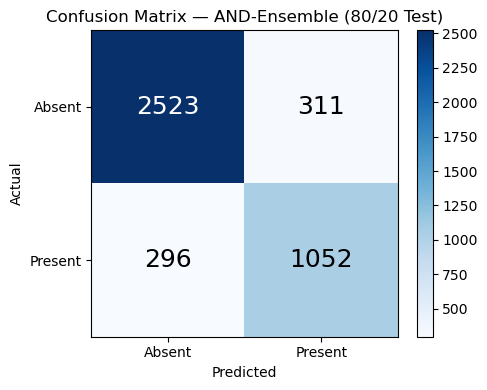

In [6]:
# === Confusion matrix + test metrics (AND-ensemble) — the "matrix test" ===
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = (np.minimum(a, b) >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred); tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX (AND-ensemble, 80/20 test set)")
print(f"                 Predicted Absent   Predicted Present")
print(f"Actually Absent      TN = {tn:>5d}         FP = {fp:>5d}")
print(f"Actually Present     FN = {fn:>5d}         TP = {tp:>5d}\n")

acc = (tp + tn) / (tp + tn + fp + fn); prec = tp / (tp + fp); rec = tp / (tp + fn)
spec = tn / (tn + fp); f1 = 2 * prec * rec / (prec + rec)
print("TEST METRICS (from the confusion matrix):")
print(f"  Accuracy    : {acc:.4f}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  Specificity : {spec:.4f}")
print(f"  F1 Score    : {f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Absent", "Present"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Absent", "Present"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — AND-Ensemble (80/20 Test)")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


In [7]:
# === Model 2B span extractor: token-F1 / Exact Match / overlap on the 20% test ===
from transformers import AutoModelForQuestionAnswering
QA_MAXLEN, FOCUS = 320, 1200
qa_tok = AutoTokenizer.from_pretrained("outputs/span/final")
qa_model = AutoModelForQuestionAnswering.from_pretrained("outputs/span/final").to(DEVICE).eval()

span_rows = []
for c in js:
    title = c["title"]
    if title not in _test: continue
    wins = windows_by_title[title]
    for qa in c["paragraphs"][0]["qas"]:
        if not qa["answers"]: continue
        q = qa["question"]
        for aa in qa["answers"]:
            at = aa["text"].strip()
            if not at: continue
            probe = at[:200]
            for w in wins:
                pos = w.find(probe)
                if pos != -1:
                    span_rows.append({"question": q, "context": w, "answer_text": at, "char_start": pos}); break
sp_test = pd.DataFrame(span_rows)

def encode_qa(batch):
    ctxs = []
    for w, cs in zip(batch["context"], batch["char_start"]):
        start_f = max(0, cs - 150); ctxs.append(w[start_f:start_f + FOCUS])
    return qa_tok(batch["question"], ctxs, truncation="only_second", max_length=QA_MAXLEN)
qa_test = Dataset.from_pandas(sp_test, preserve_index=False).map(
    encode_qa, batched=True, remove_columns=sp_test.columns.tolist())

def normalize(s):
    s = s.lower(); s = re.sub(r"\b(a|an|the)\b", " ", s)
    s = "".join(ch for ch in s if ch not in string.punctuation); return " ".join(s.split())
def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g: return float(p == g)
    common = sum((Counter(p) & Counter(g)).values())
    if common == 0: return 0.0
    pr, rc = common / len(p), common / len(g); return 2 * pr * rc / (pr + rc)

sep_id = qa_tok.sep_token_id; golds = sp_test["answer_text"].tolist()
em = f1 = overlap = 0; N = len(qa_test); B = 32
for i in range(0, N, B):
    feats = [qa_test[j] for j in range(i, min(i + B, N))]
    batch = qa_tok.pad({"input_ids": [f["input_ids"] for f in feats],
                        "attention_mask": [f["attention_mask"] for f in feats]},
                       padding=True, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = qa_model(**batch)
    sl = out.start_logits.cpu().numpy(); el = out.end_logits.cpu().numpy()
    for k, f in enumerate(feats):
        ids = f["input_ids"]; L = len(ids); sep = ids.index(sep_id)
        mask = np.full(L, -1e9); mask[sep + 1:] = 0.0
        s = int(np.argmax(sl[k][:L] + mask)); e = int(np.argmax(el[k][:L] + mask))
        if e < s: e = s
        e = min(e, s + 60)
        pred_text = qa_tok.decode(ids[s:e + 1], skip_special_tokens=True)
        g = golds[i + k]
        em += int(normalize(pred_text) == normalize(g)); tf = token_f1(pred_text, g)
        f1 += tf; overlap += int(tf >= 0.5)

print(f"span extractor on {N} test examples (answer-bearing windows):")
print(f"  Exact Match     : {em/N:.1%}")
print(f"  token-F1        : {f1/N:.3f}")
print(f"  overlap (F1>=.5): {overlap/N:.1%}")


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Map:   0%|          | 0/2667 [00:00<?, ? examples/s]

span extractor on 2667 test examples (answer-bearing windows):
  Exact Match     : 35.5%
  token-F1        : 0.763
  overlap (F1>=.5): 82.7%


In [8]:
# === Model 1 summarizer: ROUGE-L on the 20% test ===
from transformers import AutoModelForSeq2SeqLM
MAX_IN, MAX_OUT = 256, 48
t5_tok = AutoTokenizer.from_pretrained("outputs/summarizer/final")
t5_model = AutoModelForSeq2SeqLM.from_pretrained("outputs/summarizer/final").to("cpu").eval()

GOLD_SUMMARIES = {
    "Document Name": "This states the official name and type of the agreement.",
    "Parties": "This identifies who is signing the contract and the role each side plays.",
    "Agreement Date": "This is the date the contract was signed.",
    "Effective Date": "This is the date the contract terms actually start applying.",
    "Expiration Date": "This is when the contract is scheduled to end.",
    "Renewal Term": "This explains how the contract continues if neither side cancels.",
    "Notice Period To Terminate Renewal": "This is how long ahead you must say you will not renew.",
    "Governing Law": "This says which country or state law decides any dispute.",
    "Most Favored Nation": "This promises you the best deal the other side gives anyone else.",
    "Non-Compete": "This restricts you from working with the other side\'s competitors.",
    "Exclusivity": "This makes one side the only allowed source or buyer for something.",
    "No-Solicit Of Customers": "You agree not to approach the other side\'s customers.",
    "Competitive Restriction Exception": "This lists where the non-compete or exclusivity does not apply.",
    "No-Solicit Of Employees": "You agree not to recruit the other side\'s employees.",
    "Non-Disparagement": "You agree not to publicly criticise the other side.",
    "Termination For Convenience": "Either side can end the contract for any reason with notice.",
    "Rofr/Rofo/Rofn": "You get the first chance to match an offer or take an opportunity.",
    "Change Of Control": "This explains what happens if one company is bought or merges.",
    "Anti-Assignment": "You cannot transfer this contract to someone else without permission.",
    "Revenue/Profit Sharing": "You share a portion of revenue or profit with the other side.",
    "Price Restrictions": "This limits what prices you can charge or change.",
    "Minimum Commitment": "You promise to buy or deliver at least a stated minimum amount.",
    "Volume Restriction": "There is a cap on how much you can sell or distribute.",
    "Ip Ownership Assignment": "Any new intellectual property created belongs to the named owner.",
    "Joint Ip Ownership": "Both sides jointly own intellectual property created under this contract.",
    "License Grant": "This grants permission to use the other side\'s intellectual property.",
    "Non-Transferable License": "You cannot pass this licence to anyone else.",
    "Affiliate License-Licensor": "The licensor\'s affiliates also grant you rights here.",
    "Affiliate License-Licensee": "Your affiliates can use the licence too.",
    "Unlimited/All-You-Can-Eat-License": "The licence is unlimited in scope or volume.",
    "Irrevocable Or Perpetual License": "The licence cannot be taken away and may last forever.",
    "Source Code Escrow": "Source code is held by a third party in case something goes wrong.",
    "Post-Termination Services": "Some services continue for a while after the contract ends.",
    "Audit Rights": "The other side can inspect your records to check compliance.",
    "Uncapped Liability": "There is no limit on how much one side may owe in damages.",
    "Cap On Liability": "There is a maximum amount one side may owe in damages.",
    "Liquidated Damages": "A fixed amount is owed for specific breaches, agreed in advance.",
    "Warranty Duration": "This is how long the warranty lasts.",
    "Insurance": "You must keep specified insurance coverage in force.",
    "Covenant Not To Sue": "You agree not to sue the other side over the listed matters.",
    "Third Party Beneficiary": "Someone not signing the contract still gets to enforce part of it.",
}

sum_rows = []
for c in js:
    if c["title"] not in _test: continue
    for qa in c["paragraphs"][0]["qas"]:
        s = GOLD_SUMMARIES.get(cat_from_qid(qa["id"]))
        if not s: continue
        for a in qa["answers"]:
            at = a["text"].strip()
            if at: sum_rows.append({"input_text": f"summarize in plain English: {at[:1200]}", "target_text": s})
sum_test = pd.DataFrame(sum_rows)

def lcs_len(a, b):
    dp = [0] * (len(b) + 1)
    for i in range(1, len(a) + 1):
        prev = 0
        for j in range(1, len(b) + 1):
            tmp = dp[j]; dp[j] = prev + 1 if a[i-1] == b[j-1] else max(dp[j], dp[j-1]); prev = tmp
    return dp[-1]
def rouge_l(pred, gold):
    p, g = pred.lower().split(), gold.lower().split()
    if not p or not g: return 0.0
    l = lcs_len(p, g)
    if l == 0: return 0.0
    pr, rc = l / len(p), l / len(g); return 2 * pr * rc / (pr + rc)

samp = sum_test.sample(150, random_state=SEED).reset_index(drop=True)
scores = []
for i in range(len(samp)):
    inp = t5_tok(samp.loc[i, "input_text"], return_tensors="pt", truncation=True, max_length=MAX_IN)
    out = t5_model.generate(**inp, max_new_tokens=MAX_OUT, num_beams=2)
    scores.append(rouge_l(t5_tok.decode(out[0], skip_special_tokens=True), samp.loc[i, "target_text"]))
print(f"fine-tuned summarizer ROUGE-L on 150 test clauses : {np.mean(scores):.3f}")


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


fine-tuned summarizer ROUGE-L on 150 test clauses : 0.775


In [9]:
# === Zero-shot vs fine-tuned summarizer, same clauses (qualitative) ===
zs_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to("cpu").eval()
demo = sum_test.sample(4, random_state=1).reset_index(drop=True)
for i in range(len(demo)):
    clause = demo.loc[i, "input_text"].replace("summarize in plain English: ", "")
    enc = t5_tok(demo.loc[i, "input_text"], return_tensors="pt", truncation=True, max_length=256)
    ft = t5_tok.decode(t5_model.generate(**enc, max_new_tokens=40)[0], skip_special_tokens=True)
    zs = t5_tok.decode(zs_model.generate(**enc, max_new_tokens=40)[0], skip_special_tokens=True)
    print(f"--- clause {i+1} ---")
    print("clause    :", clause[:160])
    print("gold      :", demo.loc[i, "target_text"])
    print("fine-tuned:", ft)
    print("zero-shot :", zs)
    print()


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


--- clause 1 ---
clause    : New Process Technologies that have been developed by Eutectix, alone or with a third party, shall be solely owned by Eutectix, and, if permitted, Eutectix shall
gold      : This grants permission to use the other side's intellectual property.
fine-tuned: This grants permission to use the other side's intellectual property.
zero-shot : New Process Technologies that have been developed by Eutectix, alone or with a third party, shall be solely owned by Eutectix and, if permitted, Eutect

--- clause 2 ---
clause    : KPN Telecom B.V.
gold      : This identifies who is signing the contract and the role each side plays.
fine-tuned: This identifies who is signing the contract and the role each side plays.
zero-shot : KPN Telecom B.V.



--- clause 3 ---
clause    : PaperExchange hereby grants VerticalNet an exclusive license to use, modify, enhance, reproduce, display, perform and transmit the PaperExchange Content, subjec
gold      : This grants permission to use the other side's intellectual property.
fine-tuned: This makes one side the only allowed source or buyer for something.
zero-shot : PaperExchange shall grant VerticalNet an exclusive license to use, modify, enhance, reproduce, display, perform and transmit the PaperExchange Content, subject to and in accordance with the terms,

--- clause 4 ---
clause    : Licensor
gold      : This identifies who is signing the contract and the role each side plays.
fine-tuned: This identifies who is signing the contract and the role each side plays.
zero-shot : a licensor

